In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle
from matplotlib.colors import ListedColormap

In [10]:
def plot_heatmap(df, x_col, y_col, value_col, fixed_col, fixed_val, fig, ax, v_min=None, v_max=None):
    """
    Plots a heatmap for two variables while holding a third variable constant.
    - No limits: Symmetric 'vlag' centered at 0.
    - Limits provided: Sequential 'Reds' colormap.
    """
    # 1. Filter the dataframe
    filtered_df = df[np.isclose(df[fixed_col], fixed_val)]
    
    if filtered_df.empty:
        print(f"Warning: No data found where {fixed_col} == {fixed_val}")
        return ax

    # 2. Pivot the filtered data
    try:
        pivot_table = filtered_df.pivot(index=y_col, columns=x_col, values=value_col)
    except ValueError:
        pivot_table = filtered_df.pivot_table(index=y_col, columns=x_col, 
                                              values=value_col, aggfunc='mean')

    # 3. Handle Symmetry and Colormap Logic
    if v_min is None and v_max is None:
        # Symmetric mode
        limit = np.abs(pivot_table.values).max()
        v_min, v_max = -limit, limit
        cmap = "vlag"
        center = 0
    else:
        # Sequential "Red" Mode using only the second half of vlag
        vlag_full = plt.get_cmap("vlag")
        # Get the colors from the 50% mark to 100% mark
        red_half_colors = vlag_full(np.linspace(0.5, 1, 256))
        cmap = ListedColormap(red_half_colors)
        center = None

    # 4. Plot
    sns.heatmap(pivot_table, annot=False, cmap=cmap, ax=ax, 
                vmin=v_min, vmax=v_max, center=center)
    
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    
    return ax

def create_heatmaps(df_aut, df_naut, diff_df, metric, fixed_values, v_min = None, v_max = None):
    # each row will be a different set of inputs
    fig, ax = plt.subplots(3, 3, figsize = (12, 8), sharex = 'col', sharey = 'row')
    fig.tight_layout()
    fig.suptitle(f'- - {metric} - -', x = 0.49, y = 1.0)

    # Injected vs w1
    plot_heatmap(df_aut, 'I_inj', 'w_e1_e2', metric, 'w_e2_e1', fixed_values[0], fig = fig, ax = ax[0, 0], v_min = v_min, v_max = v_max)
    plot_heatmap(df_naut, 'I_inj', 'w_e1_e2', metric, 'w_e2_e1', fixed_values[0], fig = fig, ax = ax[1, 0], v_min = v_min, v_max = v_max)
    plot_heatmap(diff_df, 'I_inj', 'w_e1_e2', metric, 'w_e2_e1', fixed_values[0], fig = fig, ax = ax[2, 0], v_min = None, v_max = None)

    # Injected vs w2
    plot_heatmap(df_aut, 'I_inj', 'w_e2_e1', metric, 'w_e1_e2', fixed_values[1], fig = fig, ax = ax[0, 1], v_min = v_min, v_max = v_max)
    plot_heatmap(df_naut, 'I_inj', 'w_e2_e1', metric, 'w_e1_e2', fixed_values[1], fig = fig, ax = ax[1, 1], v_min = v_min, v_max = v_max)
    plot_heatmap(diff_df, 'I_inj', 'w_e2_e1', metric, 'w_e1_e2', fixed_values[1], fig = fig, ax = ax[2, 1], v_min = None, v_max = None)

    # w1 vs w2
    plot_heatmap(df_aut, 'w_e1_e2', 'w_e2_e1', metric, 'I_inj', fixed_values[2], fig = fig, ax = ax[0, 2], v_min = v_min, v_max = v_max)
    plot_heatmap(df_naut, 'w_e1_e2', 'w_e2_e1', metric, 'I_inj', fixed_values[2], fig = fig, ax = ax[1, 2], v_min = v_min, v_max = v_max)
    plot_heatmap(diff_df, 'w_e1_e2', 'w_e2_e1', metric, 'I_inj', fixed_values[2], fig = fig, ax = ax[2, 2], v_min = None, v_max = None)

    rows = ["Autaptic Neuron", "Non-Autaptic Neuron", "Difference"]
    for axes, row_label in zip(ax[:,0], rows):
        axes.annotate(row_label, xy=(0, 0.5), xytext=(-axes.yaxis.labelpad - 5, 0),
                    xycoords=axes.yaxis.label, textcoords='offset points',
                    size='large', ha='right', va='center', rotation=90)
    
    return fig, ax

In [11]:
with open('synch_analysis_aut.pickle', 'rb') as file:
    df_aut = pickle.load(file)

with open('synch_analysis_naut.pickle', 'rb') as file:
    df_naut = pickle.load(file)

print(df_aut.keys())

df_aut['I_inj'] = df_aut['I_inj'].round(0)
df_aut['w_e1_e2'] = df_aut['w_e1_e2'].round(0)
df_aut['w_e2_e1'] = df_aut['w_e2_e1'].round(0)

df_naut['I_inj'] = df_naut['I_inj'].round(0)
df_naut['w_e1_e2'] = df_naut['w_e1_e2'].round(0)
df_naut['w_e2_e1'] = df_naut['w_e2_e1'].round(0)


#Create a difference dataframe
diff_df = df_aut.copy()
diff_df['FT_distance'] = df_aut['FT_distance'] - df_naut['FT_distance']
diff_df['ISI_distance'] = df_aut['ISI_distance'] - df_naut['ISI_distance']
diff_df['SPIKE_distance'] = df_aut['SPIKE_distance'] - df_naut['SPIKE_distance']
diff_df['SPIKE_synchrony'] = df_aut['SPIKE_synchrony'] - df_naut['SPIKE_synchrony']
diff_df['spike_directionality'] = df_aut['spike_directionality'] - df_naut['spike_directionality']

print(df_aut['I_inj'].unique())
print(df_naut['w_e1_e2'].unique())
print(df_aut['w_e2_e1'].unique())

FIXED_VALUES = [82, 82, 213]

Index(['I_inj', 'w_e1_e2', 'w_e2_e1', 'FT_distance', 'ISI_distance',
       'SPIKE_distance', 'SPIKE_synchrony', 'spike_directionality'],
      dtype='object')
[120. 128. 137. 145. 154. 162. 171. 179. 187. 196. 204. 213. 221. 229.
 238. 246. 255. 263. 272. 280.]
[ 20.  29.  38.  47.  56.  64.  73.  82.  91. 100.]
[ 20.  29.  38.  47.  56.  64.  73.  82.  91. 100.]


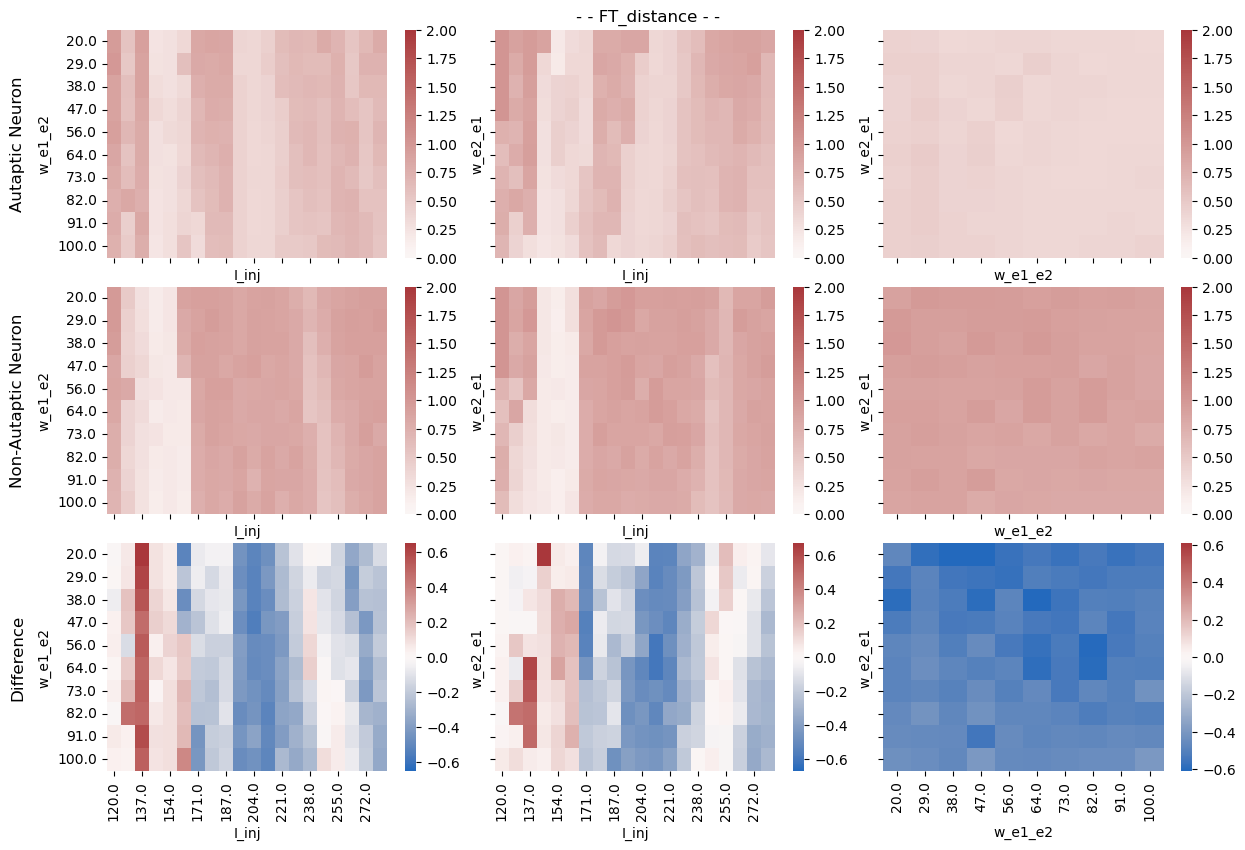

In [12]:
'''- - PLOT FT DISTANCE - -'''
# each row will be a different set of inputs
fig, ax = create_heatmaps(df_aut, df_naut, diff_df, metric = 'FT_distance', fixed_values = FIXED_VALUES, v_min = 0, v_max = 2)


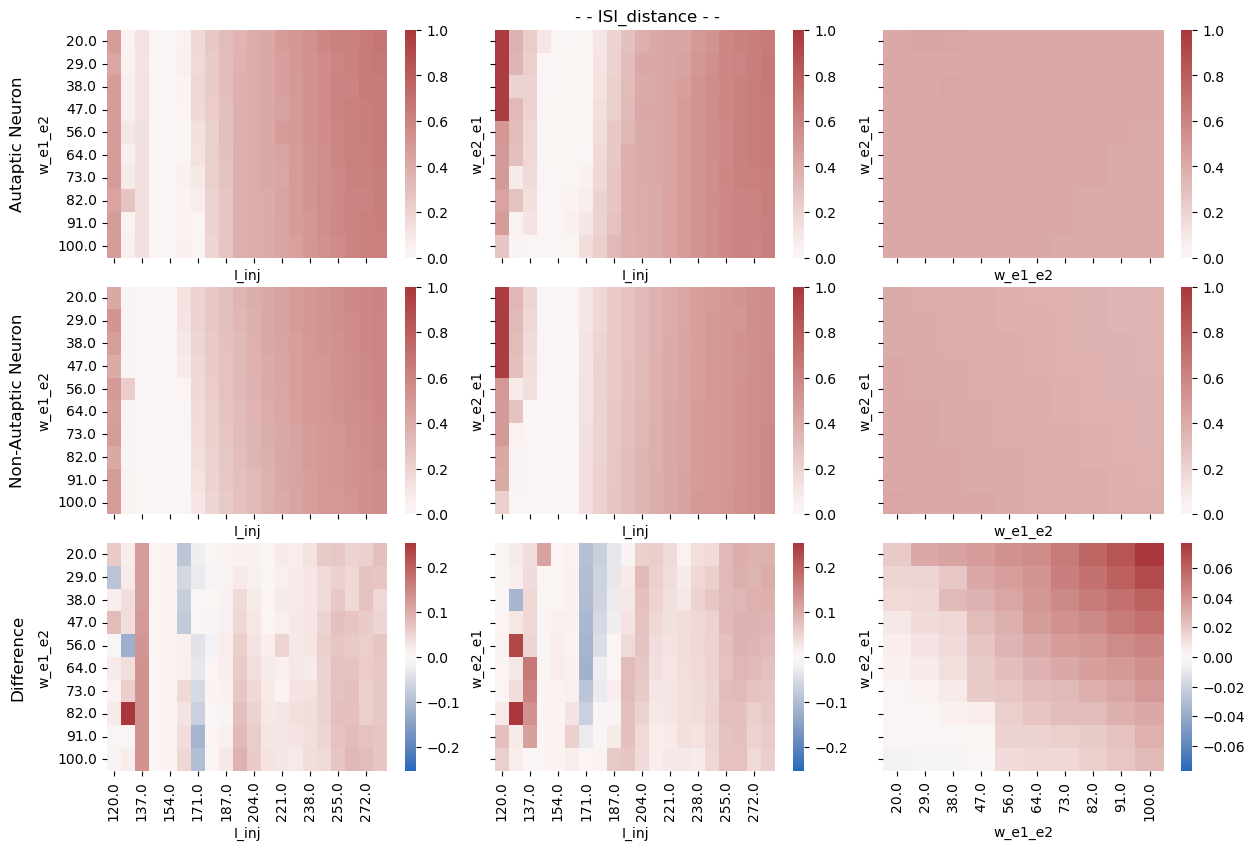

In [13]:
'''- - PLOT ISI DISTANCE - -'''
fig, ax = create_heatmaps(df_aut, df_naut, diff_df, metric = 'ISI_distance', fixed_values = FIXED_VALUES, v_min = 0, v_max = 1)

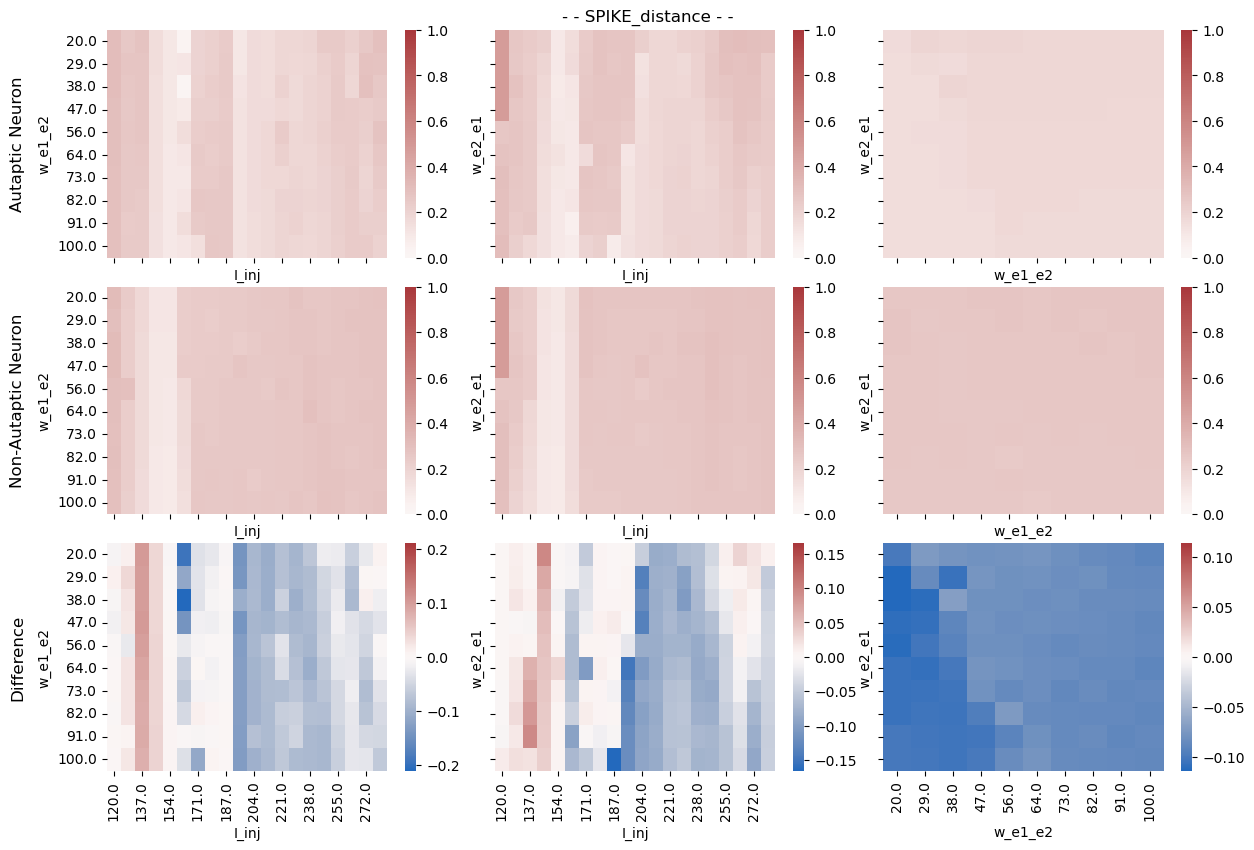

In [14]:
'''- - PLOT SPIKE DISTANCE - -'''
fig, ax = create_heatmaps(df_aut, df_naut, diff_df, metric = 'SPIKE_distance', fixed_values = FIXED_VALUES, v_min = 0, v_max = 1)

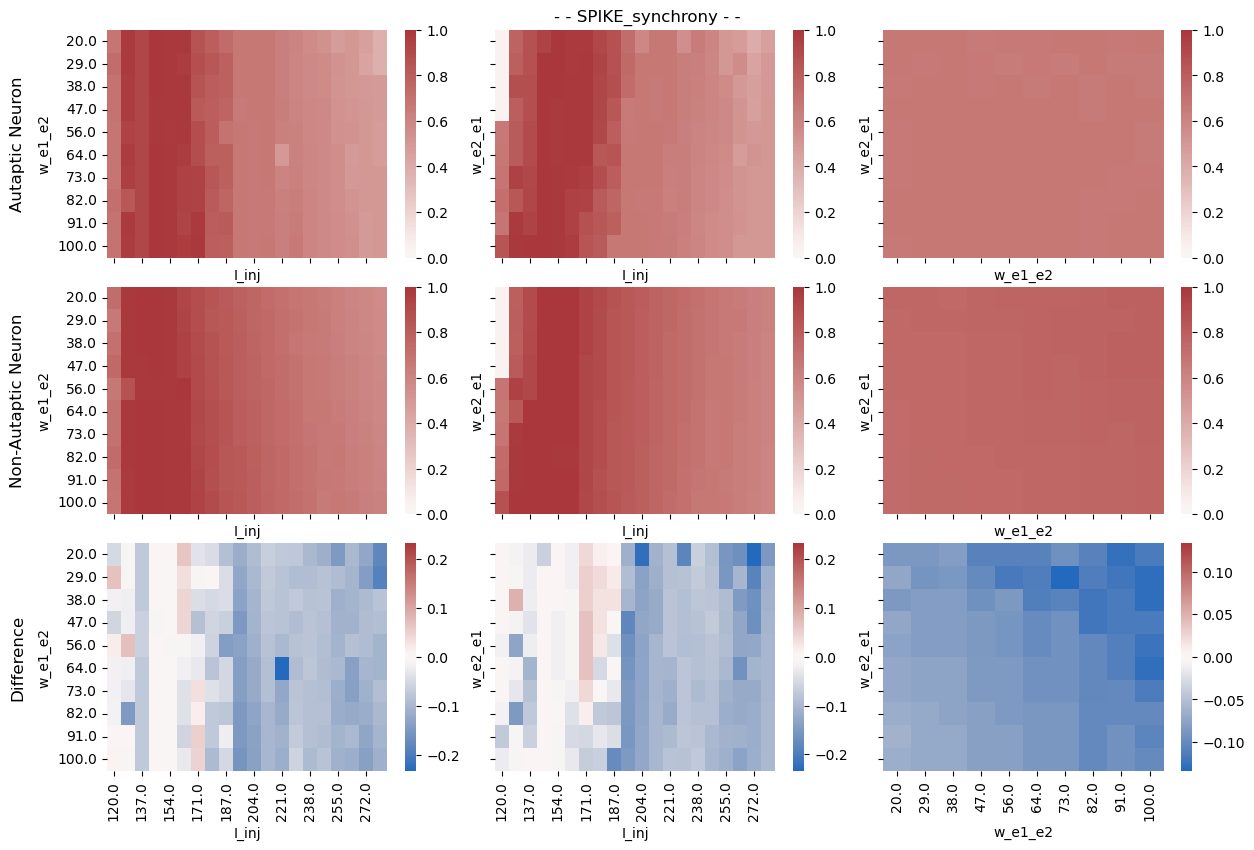

In [15]:
'''- - PLOT SPIKE SYNCHRONY - -'''
fig, ax = create_heatmaps(df_aut, df_naut, diff_df, metric = 'SPIKE_synchrony', fixed_values = FIXED_VALUES, v_min = 0, v_max = 1)

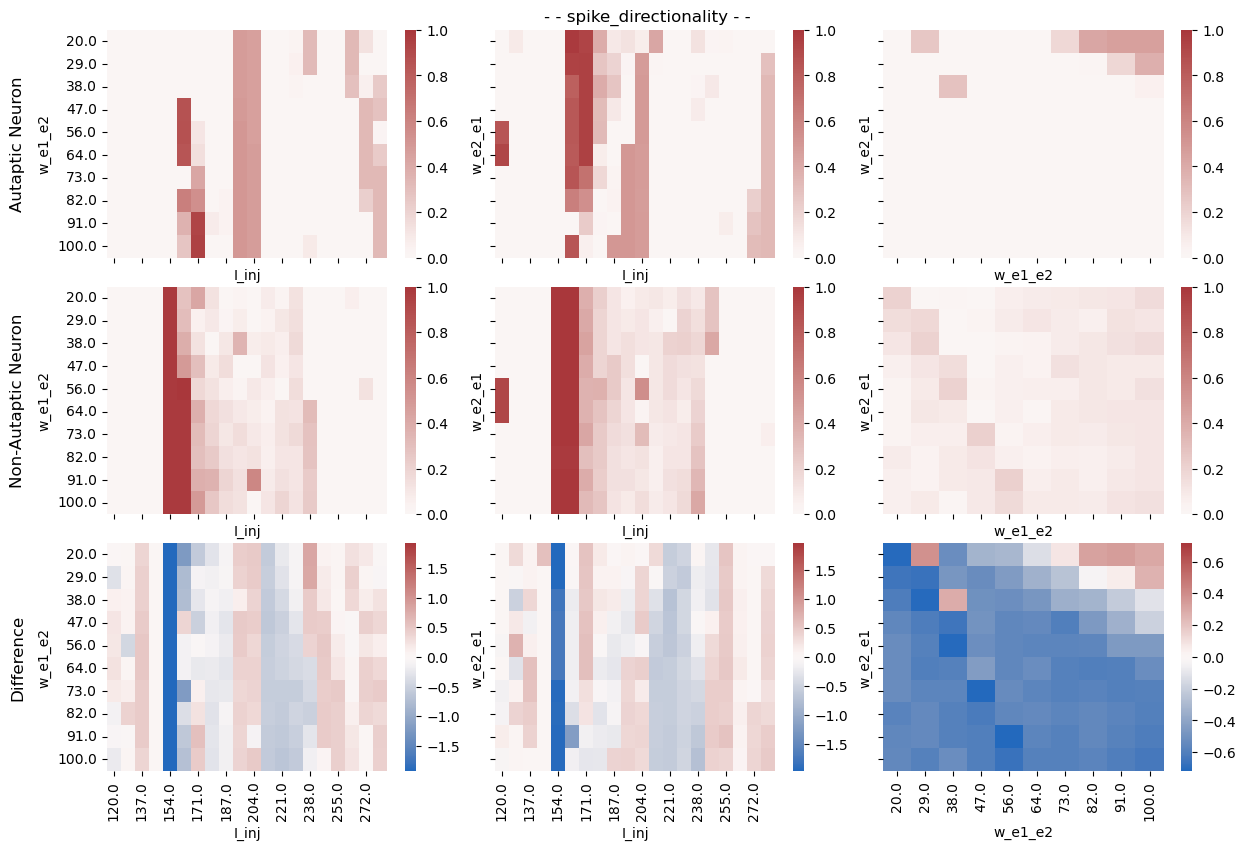

In [16]:
'''- - PLOT SPIKE DIRECTIONALITY (<0 means E1 leads) - -'''
fig, ax = create_heatmaps(df_aut, df_naut, diff_df, metric = 'spike_directionality', fixed_values = FIXED_VALUES, v_min = 0, v_max = 1)